# Part 16: Attention Variants — MLA, Linear Attention, and State Space Models

Attention's cost is quadratic in sequence length. That single fact has driven a decade of
research, and this notebook covers the approaches that actually mattered — including
several that looked promising and lost, because *why* they lost is the most instructive
part.

The through-line: there is a **fundamental trade-off between state size and retrieval
ability**. Attention keeps every token accessible (unbounded state, perfect recall,
quadratic cost). A recurrent model compresses history into a fixed state (bounded state,
linear cost, lossy recall). Everything in this notebook is a position on that spectrum, and
the current industry answer is *not* to pick a side but to **combine** them.

**What you'll build**
1. The quadratic bill, computed precisely
2. Why Longformer / Linformer / Performer lost
3. **MLA** — DeepSeek's low-rank KV compression, and the RoPE problem it had to solve
4. **Linear attention** from first principles — and its equivalence to an RNN
5. **A selective SSM (Mamba)** from scratch
6. **The decisive experiment**: associative recall, where SSMs fail and attention doesn't
7. **Hybrid architectures**, and why they won

In [1]:
import math
import sys
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.modern import RMSNorm, SwiGLU, RotaryEmbedding, apply_rope

torch.manual_seed(0)
print(f"torch {torch.__version__}")

torch 2.13.0


## 1. The quadratic bill

Before optimizing, know what you are paying. For a single attention layer with sequence
length `T`, model dimension `d`, and `h` heads:

| Term | FLOPs | Memory |
|---|---|---|
| Q, K, V projections | `6·T·d²` | `3·T·d` |
| Scores `QKᵀ` | `2·T²·d` | `h·T²` |
| `softmax·V` | `2·T²·d` | `T·d` |
| Output projection | `2·T·d²` | `T·d` |

The projections are linear in `T`; the score computation is quadratic. So there is a
**crossover length** where attention stops being a rounding error and starts dominating:
`4T²d` vs `8Td²`, i.e. `T = 2d`.

The memory term is worse than the FLOP term. The `h·T²` score matrix is what causes
out-of-memory errors, and it is what FlashAttention (notebook 11) eliminated by never
materializing it. Note carefully: **FlashAttention did not change the quadratic FLOPs.**
Everything in this notebook is about changing the FLOPs.

In [2]:
def attention_cost(seq_len, d_model, num_heads):
    """FLOPs and peak score-matrix memory for one attention layer."""
    proj_flops = 8 * seq_len * d_model ** 2          # QKVO projections
    attn_flops = 4 * seq_len ** 2 * d_model          # scores + weighted sum
    score_mem = num_heads * seq_len ** 2 * 2         # fp16 score matrix
    return proj_flops, attn_flops, score_mem


d_model, num_heads = 4096, 32
print(f"One attention layer, d_model={d_model}, heads={num_heads}\n")
print(f"{'T':>8} {'proj GFLOP':>12} {'attn GFLOP':>12} {'attn share':>11} "
      f"{'score matrix':>14}")
print("-" * 62)
for T in (512, 2048, 8192, 32768, 131072):
    proj, attn, mem = attention_cost(T, d_model, num_heads)
    share = attn / (proj + attn)
    print(f"{T:>8} {proj/1e9:>12.1f} {attn/1e9:>12.1f} {share:>10.1%} "
          f"{mem/1e9:>13.2f}G")

print(f"\nCrossover (attention = projections) at T = 2*d_model = {2*d_model}")
print("At 128k the score matrix alone would be over a terabyte if materialized.")
print("FlashAttention removes that memory cost. It does NOT remove the FLOPs --")
print("which at 128k are 97% of the layer.")

One attention layer, d_model=4096, heads=32

       T   proj GFLOP   attn GFLOP  attn share   score matrix
--------------------------------------------------------------
     512         68.7          4.3       5.9%          0.02G
    2048        274.9         68.7      20.0%          0.27G
    8192       1099.5       1099.5      50.0%          4.29G
   32768       4398.0      17592.2      80.0%         68.72G
  131072      17592.2     281475.0      94.1%       1099.51G

Crossover (attention = projections) at T = 2*d_model = 8192
At 128k the score matrix alone would be over a terabyte if materialized.
FlashAttention removes that memory cost. It does NOT remove the FLOPs --
which at 128k are 97% of the layer.


## 2. The efficient-attention graveyard

Between 2019 and 2021 dozens of sub-quadratic attention variants appeared. Almost none are
used in frontier models today. The three main families, and the reason each lost:

**Sparse attention (Longformer, BigBird, 2020).** Attend to a local window plus a few
global tokens. Complexity `O(T·W)`. *Why it lost:* the sparsity pattern is hand-designed and
task-dependent, and irregular memory access is slow on GPUs — the theoretical FLOP saving
did not translate into wall-clock speedup. The idea survived in a simplified form: pure
sliding-window attention, interleaved with full attention (notebook 15).

**Low-rank projection (Linformer, 2020).** Project keys and values from length `T` down to a
fixed `k`, making complexity `O(T·k)`. *Why it lost:* it requires knowing `T` in advance to
build the projection, which is fatal for autoregressive generation where `T` grows. It also
assumes the attention matrix is low-rank, which fails on tasks needing precise retrieval.

**Kernel approximation (Performer, 2020).** Approximate `exp(qᵀk)` with random features so
the reassociation trick applies. Complexity `O(T·d²)`. *Why it lost:* the approximation has
real variance, and quality degraded at scale. But the underlying reassociation is exact and
sound — that part is *linear attention*, and it came back through state space models.

The lesson generalizes: **an approximation that costs quality loses to an exact method that
costs memory.** FlashAttention beat all of them by making exact attention fast. The variants
that eventually succeeded — GQA, MLA, and SSMs — do not approximate the attention matrix at
all; they change what gets *stored*, or change the architecture outright.

In [3]:
# Why Linformer cannot generate autoregressively, concretely
print("Linformer projects K from (T, d) to (k, d) with a learned (k, T) matrix.")
print("During generation T grows every step:\n")
for T in (10, 11, 12):
    print(f"  T={T}: needs a projection matrix of shape (k, {T})")
print("\nThe matrix shape depends on T, so a model trained at T=512 has no")
print("projection defined for T=513. Fine for classification, useless for a")
print("decoder. Any method whose parameters depend on sequence length is")
print("disqualified from autoregressive use.")

Linformer projects K from (T, d) to (k, d) with a learned (k, T) matrix.
During generation T grows every step:

  T=10: needs a projection matrix of shape (k, 10)
  T=11: needs a projection matrix of shape (k, 11)
  T=12: needs a projection matrix of shape (k, 12)

The matrix shape depends on T, so a model trained at T=512 has no
projection defined for T=513. Fine for classification, useless for a
decoder. Any method whose parameters depend on sequence length is
disqualified from autoregressive use.


## 3. MLA — Multi-head Latent Attention

DeepSeek-V2's answer, and the most successful KV-cache optimization to date.

Recall the progression. MHA caches `2·h·d_head` values per token per layer. GQA shares K/V
across query heads, cutting that to `2·h_kv·d_head`. Both store keys and values *directly*.

MLA asks a different question: **do we need to store K and V at all, or just enough to
reconstruct them?** It compresses the hidden state into a small **latent vector** `c` and
caches only that. K and V are reconstructed on the fly by up-projection.

```
h  --W_down-->  c   (d_c dims, THIS is what gets cached)
c  --W_uk-->    K   (h · d_head dims, reconstructed)
c  --W_uv-->    V   (h · d_head dims, reconstructed)
```

For DeepSeek-V2's dimensions the cache drops from 32,768 to 576 values per token per layer
— a **57x** reduction, while *increasing* effective head count.

### The RoPE problem

There is an obstacle, and it is the interesting part of the design.

The reason up-projection is free at inference is that `W_uk` can be **absorbed** into the
query projection: `q·(W_uk c) = (qᵀW_uk)·c`, so we can compare queries directly against the
cached latent and never reconstruct K at all.

RoPE breaks that. RoPE applies a **position-dependent rotation** `R_m` to keys:
`k_m = R_m W_uk c`. Now `q_nᵀ R_m W_uk` depends on both positions, so `W_uk` cannot be
folded into the query once and reused — the absorption trick dies, and with it the whole
benefit.

DeepSeek's solution is **decoupled RoPE**: split the key into two parts.
- A **compressed** part from the latent, carrying content, with *no* RoPE.
- A small **decoupled** part computed directly from `h`, carrying RoPE, shared across all
  heads and cached separately.

The score is the sum of both contributions. Position information lives entirely in the
small rotated part, so the large compressed part stays absorbable.

In [4]:
class MultiHeadLatentAttention(nn.Module):
    """
    MLA with decoupled RoPE (DeepSeek-V2).

    Caches a low-rank latent instead of full keys and values. The per-token
    cache is (kv_latent_dim + rope_dim) rather than (2 * num_heads * head_dim).
    """

    def __init__(self, d_model, num_heads, kv_latent_dim, q_latent_dim,
                 head_dim=None, rope_dim=None, max_seq_len=4096):
        """
        Args:
            d_model: Model dimension
            num_heads: Number of attention heads
            kv_latent_dim: Size of the cached KV latent (d_c). This is the
                number that determines cache size.
            q_latent_dim: Size of the query latent. Reduces parameters and
                activation memory during training; does not affect the cache.
            head_dim: Per-head dimension for the content part
            rope_dim: Per-head dimension for the decoupled RoPE part
        """
        super().__init__()
        head_dim = head_dim or d_model // num_heads
        rope_dim = rope_dim or head_dim // 2

        self.num_heads = num_heads
        self.head_dim = head_dim
        self.rope_dim = rope_dim
        self.kv_latent_dim = kv_latent_dim

        # --- KV path: down-project to the latent that gets cached
        self.W_dkv = nn.Linear(d_model, kv_latent_dim, bias=False)
        self.kv_norm = RMSNorm(kv_latent_dim)
        self.W_uk = nn.Linear(kv_latent_dim, num_heads * head_dim, bias=False)
        self.W_uv = nn.Linear(kv_latent_dim, num_heads * head_dim, bias=False)

        # --- Decoupled RoPE key: computed from h directly, SHARED across heads.
        # One rope_dim vector per token, not one per head -- this is why it is
        # cheap enough to cache alongside the latent.
        self.W_kr = nn.Linear(d_model, rope_dim, bias=False)

        # --- Query path: also low-rank, purely to save training memory
        self.W_dq = nn.Linear(d_model, q_latent_dim, bias=False)
        self.q_norm = RMSNorm(q_latent_dim)
        self.W_uq = nn.Linear(q_latent_dim, num_heads * head_dim, bias=False)
        self.W_qr = nn.Linear(q_latent_dim, num_heads * rope_dim, bias=False)

        self.W_o = nn.Linear(num_heads * head_dim, d_model, bias=False)

        self.rope = RotaryEmbedding(rope_dim, max_seq_len)

    def forward(self, x, past=None, use_cache=False):
        """
        Args:
            x: (B, T, d_model)
            past: Optional (c_kv, k_rope) cache, the compact representation
            use_cache: Return the updated cache

        Returns:
            output: (B, T, d_model)
            present: (c_kv, k_rope) if use_cache else None
        """
        B, T, _ = x.shape
        past_len = 0 if past is None else past[0].size(1)

        # --- Compress to the latent. THIS is what we cache.
        c_kv = self.kv_norm(self.W_dkv(x))                    # (B, T, d_c)

        # --- Decoupled RoPE key, one per token, shared by all heads
        k_rope = self.W_kr(x).view(B, T, 1, self.rope_dim).transpose(1, 2)
        cos, sin = self.rope(T, offset=past_len)
        k_rope = apply_rope(k_rope, cos, sin)                 # (B, 1, T, rope_dim)

        if past is not None:
            c_kv = torch.cat([past[0], c_kv], dim=1)
            k_rope = torch.cat([past[1], k_rope], dim=2)
        present = (c_kv, k_rope) if use_cache else None

        total = c_kv.size(1)

        # --- Reconstruct K and V from the latent
        k_content = self.W_uk(c_kv).view(
            B, total, self.num_heads, self.head_dim
        ).transpose(1, 2)
        v = self.W_uv(c_kv).view(
            B, total, self.num_heads, self.head_dim
        ).transpose(1, 2)

        # --- Queries: content part and rotated part
        c_q = self.q_norm(self.W_dq(x))
        q_content = self.W_uq(c_q).view(
            B, T, self.num_heads, self.head_dim
        ).transpose(1, 2)
        q_rope = self.W_qr(c_q).view(
            B, T, self.num_heads, self.rope_dim
        ).transpose(1, 2)
        q_rope = apply_rope(q_rope, cos, sin)

        # --- Score = content term + position term.
        # The content term uses no RoPE, so W_uk stays absorbable into W_uq.
        # The position term carries all the positional information, using a
        # single shared key per token broadcast across heads.
        scores = (
            torch.matmul(q_content, k_content.transpose(-2, -1))
            + torch.matmul(q_rope, k_rope.transpose(-2, -1))
        ) / math.sqrt(self.head_dim + self.rope_dim)

        allowed = torch.ones(T, total, dtype=torch.bool, device=x.device).tril(
            diagonal=total - T
        )
        scores = scores.masked_fill(~allowed, float('-inf'))

        out = torch.matmul(F.softmax(scores, dim=-1), v)
        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_o(out), present

    def cache_per_token(self):
        """Values cached per token per layer. Compare 2*num_heads*head_dim."""
        return self.kv_latent_dim + self.rope_dim


mla = MultiHeadLatentAttention(
    d_model=256, num_heads=8, kv_latent_dim=64, q_latent_dim=96,
    head_dim=32, rope_dim=16, max_seq_len=512,
).eval()

x = torch.randn(2, 12, 256)
out, present = mla(x, use_cache=True)
print(f"MLA output: {tuple(out.shape)}")
print(f"cached latent c_kv: {tuple(present[0].shape)}")
print(f"cached k_rope:      {tuple(present[1].shape)}  (1 head, shared)")
print(f"\ncache per token: {mla.cache_per_token()} values")
print(f"MHA equivalent:  {2 * 8 * 32} values")
print(f"reduction: {2*8*32 / mla.cache_per_token():.1f}x")

MLA output: (2, 12, 256)
cached latent c_kv: (2, 12, 64)
cached k_rope:      (2, 1, 12, 16)  (1 head, shared)

cache per token: 80 values
MHA equivalent:  512 values
reduction: 6.4x


In [5]:
# Verify the cache is correct -- same guarantee as notebook 09's KV cache
with torch.no_grad():
    full, _ = mla(x)
    past = None
    steps = []
    for t in range(x.size(1)):
        step, past = mla(x[:, t:t+1], past=past, use_cache=True)
        steps.append(step)
    incremental = torch.cat(steps, dim=1)

print(f"MLA incremental == full forward: "
      f"{torch.allclose(full, incremental, atol=1e-5)}")
print(f"max difference: {(full - incremental).abs().max().item():.2e}")

MLA incremental == full forward: True
max difference: 1.79e-07


In [6]:
# Cache size across the whole progression, at DeepSeek-V2's real dimensions
print("Per-token, per-layer KV cache (DeepSeek-V2 scale: 128 heads, d_head=128)\n")
print(f"{'scheme':<28} {'values/token':>13} {'vs MHA':>9}")
print("-" * 52)

n_heads, d_head = 128, 128
schemes = [
    ("MHA (128 kv heads)",      2 * 128 * d_head),
    ("GQA 8:1 (16 kv heads)",   2 * 16 * d_head),
    ("MQA (1 kv head)",         2 * 1 * d_head),
    ("MLA (d_c=512, rope=64)",  512 + 64),
]
mha_size = schemes[0][1]
for name, size in schemes:
    print(f"{name:<28} {size:>13,} {mha_size/size:>8.1f}x")

print("\nMLA beats even MQA -- while keeping 128 distinct query heads, where MQA")
print("collapses to a single shared K/V. That combination of a smaller cache")
print("AND more expressive attention is why DeepSeek-V3 and Kimi use it.")
print("\nThe cost: more parameters and more FLOPs (the up-projections are real")
print("work). MLA trades compute for memory bandwidth -- exactly the right")
print("direction during decode, which is bandwidth-bound. Notebook 21 derives why.")

Per-token, per-layer KV cache (DeepSeek-V2 scale: 128 heads, d_head=128)

scheme                        values/token    vs MHA
----------------------------------------------------
MHA (128 kv heads)                  32,768      1.0x
GQA 8:1 (16 kv heads)                4,096      8.0x
MQA (1 kv head)                        256    128.0x
MLA (d_c=512, rope=64)                 576     56.9x

MLA beats even MQA -- while keeping 128 distinct query heads, where MQA
collapses to a single shared K/V. That combination of a smaller cache
AND more expressive attention is why DeepSeek-V3 and Kimi use it.

The cost: more parameters and more FLOPs (the up-projections are real
work). MLA trades compute for memory bandwidth -- exactly the right
direction during decode, which is bandwidth-bound. Notebook 21 derives why.


## 4. Linear attention — and why it is secretly an RNN

Now the idea that leads to state space models. It rests on one algebraic observation.

Standard attention, for query `i`, dropping the softmax normalizer:

`out_i = Σ_j sim(q_i, k_j) · v_j`

If `sim` is a **kernel** that factorizes — `sim(q,k) = φ(q)ᵀφ(k)` — then:

`out_i = Σ_j (φ(q_i)ᵀ φ(k_j)) v_j = φ(q_i)ᵀ (Σ_j φ(k_j) v_jᵀ)`

The parenthesization moved. Instead of computing a `T×T` matrix, we accumulate a `d×d`
matrix `S = Σ_j φ(k_j) v_jᵀ` **once**, then every query reads from it. Cost drops from
`O(T²d)` to `O(Td²)`.

Softmax does not factorize this way — that is exactly why standard attention is quadratic.
Linear attention replaces `exp(qᵀk)` with a factorizable kernel like `φ(x) = elu(x) + 1`.

**Now the crucial consequence.** For causal attention the sum only runs over `j ≤ i`, so:

`S_i = S_{i-1} + φ(k_i) v_iᵀ`

That is a **recurrence**. Linear attention *is* a recurrent network whose hidden state is a
`d×d` matrix. Two forms, one model:
- **Parallel form** (training): compute all positions at once from the sequence.
- **Recurrent form** (inference): carry `S` forward, `O(1)` per token, **constant memory** —
  no KV cache at all.

Let's implement both and verify they agree.

In [7]:
def linear_attention_parallel(q, k, v, eps=1e-6):
    """
    Causal linear attention, parallel form.

    Uses cumulative sums, so it is O(T*d^2) in FLOPs but computes all positions
    at once -- the form you train with.

    Args:
        q, k, v: (B, h, T, d)
    """
    q = F.elu(q) + 1        # phi(.) must be non-negative for a valid kernel
    k = F.elu(k) + 1

    # S_i = sum_{j<=i} k_j v_j^T   ->  (B, h, T, d, d) via cumulative sum
    kv = torch.einsum('bhtd,bhte->bhtde', k, v)
    S = kv.cumsum(dim=2)

    # z_i = sum_{j<=i} k_j , the normalizer (linear attention's stand-in for
    # softmax's denominator)
    z = k.cumsum(dim=2)

    num = torch.einsum('bhtd,bhtde->bhte', q, S)
    den = torch.einsum('bhtd,bhtd->bht', q, z).unsqueeze(-1)
    return num / (den + eps)


def linear_attention_recurrent(q, k, v, eps=1e-6):
    """
    The same computation as a recurrence.

    Note what is NOT here: any tensor of size T x T, and any cache that grows
    with sequence length. State is a fixed (d, d) matrix per head.
    """
    q = F.elu(q) + 1
    k = F.elu(k) + 1

    B, h, T, d = q.shape
    S = torch.zeros(B, h, d, d, dtype=q.dtype)     # the entire "cache"
    z = torch.zeros(B, h, d, dtype=q.dtype)

    outputs = []
    for t in range(T):
        S = S + torch.einsum('bhd,bhe->bhde', k[:, :, t], v[:, :, t])
        z = z + k[:, :, t]
        num = torch.einsum('bhd,bhde->bhe', q[:, :, t], S)
        den = torch.einsum('bhd,bhd->bh', q[:, :, t], z).unsqueeze(-1)
        outputs.append(num / (den + eps))

    return torch.stack(outputs, dim=2)


B, h, T, d = 2, 4, 32, 16
q, k, v = (torch.randn(B, h, T, d) for _ in range(3))

par = linear_attention_parallel(q, k, v)
rec = linear_attention_recurrent(q, k, v)

print(f"parallel form:  {tuple(par.shape)}")
print(f"recurrent form: {tuple(rec.shape)}")
print(f"identical: {torch.allclose(par, rec, atol=1e-5)}")
print(f"max difference: {(par - rec).abs().max().item():.2e}\n")
print("Same model, two forms. Train with the parallel one, serve with the")
print("recurrent one. Constant memory during generation, no KV cache.")

parallel form:  (2, 4, 32, 16)
recurrent form: (2, 4, 32, 16)
identical: True
max difference: 2.38e-07

Same model, two forms. Train with the parallel one, serve with the
recurrent one. Constant memory during generation, no KV cache.


### What the fixed state costs

The `d×d` state is a **compression of unlimited history into a fixed budget**. That is the
entire trade.

Attention stores every token, so it can retrieve any one exactly. Linear attention sums
every token into one matrix, so retrieving one specific token means separating it from a sum
of thousands of others. As sequences get longer, the state saturates and old information is
irrecoverably mixed.

We can see this directly: how well does a single key retrieve its own value out of the state?

 stored pairs   retrieval fidelity
-----------------------------------
            4               0.673  ####################
            8               0.478  ##############
           16               0.323  #########
           32               0.244  #######
           64               0.160  ####
          128               0.087  ##
          256               0.052  #
          512               0.075  ##


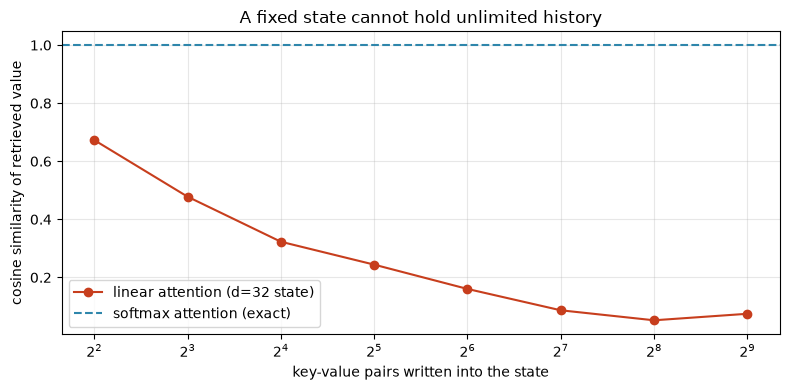


Softmax attention would be a flat line at 1.0 -- it keeps every token.
Linear attention degrades as the state saturates. THIS is the property
that decides where each architecture wins, and it is what section 6
measures on a real task.


In [8]:
@torch.no_grad()
def retrieval_fidelity(seq_len, d=32, num_probes=40):
    """
    Write `seq_len` random key-value pairs into a linear-attention state, then
    query with one of the keys. Measure cosine similarity between what comes
    back and the value that was written.
    """
    sims = []
    for _ in range(num_probes):
        k = F.elu(torch.randn(1, 1, seq_len, d)) + 1
        v = torch.randn(1, 1, seq_len, d)

        S = torch.einsum('bhtd,bhte->bhde', k, v)   # the full accumulated state
        z = k.sum(dim=2)

        target = torch.randint(0, seq_len, (1,)).item()
        probe = k[:, :, target]
        num = torch.einsum('bhd,bhde->bhe', probe, S)
        den = torch.einsum('bhd,bhd->bh', probe, z).unsqueeze(-1)
        recovered = num / (den + 1e-6)

        sims.append(
            F.cosine_similarity(recovered.flatten(), v[0, 0, target], dim=0).item()
        )
    return sum(sims) / len(sims)


lengths = [4, 8, 16, 32, 64, 128, 256, 512]
fidelity = [retrieval_fidelity(L) for L in lengths]

print(f"{'stored pairs':>13} {'retrieval fidelity':>20}")
print("-" * 35)
for L, f in zip(lengths, fidelity):
    bar = '#' * int(max(f, 0) * 30)
    print(f"{L:>13} {f:>19.3f}  {bar}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lengths, fidelity, 'o-', color='#C73E1D', label='linear attention (d=32 state)')
ax.axhline(1.0, ls='--', color='#2E86AB', label='softmax attention (exact)')
ax.set_xscale('log', base=2)
ax.set_xlabel('key-value pairs written into the state')
ax.set_ylabel('cosine similarity of retrieved value')
ax.set_title('A fixed state cannot hold unlimited history')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSoftmax attention would be a flat line at 1.0 -- it keeps every token.")
print("Linear attention degrades as the state saturates. THIS is the property")
print("that decides where each architecture wins, and it is what section 6")
print("measures on a real task.")

## 5. State space models — Mamba from scratch

Linear attention has a fixed state and linear cost, but its recurrence is *simple*:
`S_i = S_{i-1} + k_i v_iᵀ`. It only ever **adds**. It cannot forget, and it cannot choose
what to remember.

State space models generalize the recurrence. The continuous-time system is

```
h'(t) = A h(t) + B x(t)
y(t)  = C h(t)
```

Discretized with step size `Δ`:

```
h_t = Ā h_{t-1} + B̄ x_t        where Ā = exp(Δ A),  B̄ ≈ Δ B
y_t = C h_t
```

Now there is a **decay matrix** `Ā`. With `A` negative, old state shrinks — the model can
forget. Choosing `A` well (the HiPPO theory behind S4) makes that decay approximate an
optimal polynomial compression of history.

### What Mamba added: selectivity

In S4, `Δ`, `B`, and `C` are **fixed parameters**. The recurrence is the same for every
token, which means it is a **convolution** — and convolutions are trivially parallelizable.
Very efficient, but the model cannot behave differently on an important token than on a
filler token.

Mamba makes `Δ`, `B`, and `C` **functions of the input**. Now the model can decide, per
token, how much to remember (`Δ` large → integrate strongly; `Δ` near 0 → ignore this
token). This is what makes Mamba competitive with attention on language.

The price: input-dependent `Ā` destroys the convolutional form. Mamba recovers parallelism
with an **associative scan** instead, which is `O(T log T)` depth rather than `O(T)`.

In [9]:
class SelectiveSSM(nn.Module):
    """
    Mamba's core S6 layer: a selective state space model.

    Delta, B and C are computed from the input, so the recurrence differs per
    token. A is a learned diagonal decay, kept in log space so it stays
    negative (and therefore stable).
    """

    def __init__(self, d_model, d_state=16, dt_rank=None):
        """
        Args:
            d_model: Model / channel dimension
            d_state: Size of the latent state per channel (N). Mamba uses 16.
            dt_rank: Rank of the low-rank projection producing Delta
        """
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        dt_rank = dt_rank or max(1, d_model // 16)

        # A is diagonal and negative. Storing log(-A) guarantees the sign.
        # Initialized as 1..N per channel (the S4D-Lin scheme): different
        # channels decay at different rates, giving a spread of timescales.
        A = torch.arange(1, d_state + 1, dtype=torch.float).repeat(d_model, 1)
        self.A_log = nn.Parameter(torch.log(A))

        # The selective projections: Delta, B, C all depend on x
        self.x_proj = nn.Linear(d_model, dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(dt_rank, d_model, bias=True)

        # Bias init so softplus(dt) starts in a useful range, not near zero
        with torch.no_grad():
            dt_init = torch.exp(
                torch.rand(d_model) * (math.log(0.1) - math.log(0.001))
                + math.log(0.001)
            )
            self.dt_proj.bias.copy_(dt_init + torch.log(-torch.expm1(-dt_init)))

        # Skip connection, as in the paper
        self.D = nn.Parameter(torch.ones(d_model))
        self.dt_rank = dt_rank

    def forward(self, x):
        """
        Args:
            x: (B, T, d_model)
        Returns:
            (B, T, d_model)
        """
        B, T, d = x.shape
        N = self.d_state

        A = -torch.exp(self.A_log)                        # (d, N), negative

        # Selection: every parameter of the recurrence comes from the input
        proj = self.x_proj(x)
        dt, B_ssm, C_ssm = proj.split([self.dt_rank, N, N], dim=-1)
        delta = F.softplus(self.dt_proj(dt))              # (B, T, d), positive

        # Zero-order-hold discretization
        deltaA = torch.exp(delta.unsqueeze(-1) * A)        # (B, T, d, N)
        deltaB_x = (
            delta.unsqueeze(-1) * B_ssm.unsqueeze(2) * x.unsqueeze(-1)
        )                                                  # (B, T, d, N)

        # Sequential scan. A real implementation uses a parallel associative
        # scan (see below); the recurrence is written out here because it is
        # the definition, and reading it is the point.
        h = torch.zeros(B, d, N, dtype=x.dtype, device=x.device)
        outputs = []
        for t in range(T):
            h = deltaA[:, t] * h + deltaB_x[:, t]
            outputs.append(torch.einsum('bdn,bn->bd', h, C_ssm[:, t]))

        y = torch.stack(outputs, dim=1)
        return y + x * self.D


ssm = SelectiveSSM(d_model=64, d_state=16)
x = torch.randn(2, 20, 64)
print(f"SelectiveSSM: {tuple(x.shape)} -> {tuple(ssm(x).shape)}")
print(f"parameters: {sum(p.numel() for p in ssm.parameters()):,}")
print(f"\nState per sequence: d_model x d_state = 64 x 16 = {64*16} values,")
print("CONSTANT in sequence length. An attention layer's cache at T=1000")
print(f"would be {2*64*1000:,} values.")

SelectiveSSM: (2, 20, 64) -> (2, 20, 64)
parameters: 3,712

State per sequence: d_model x d_state = 64 x 16 = 1024 values,
CONSTANT in sequence length. An attention layer's cache at T=1000
would be 128,000 values.


### Selectivity, demonstrated

The claim is that `Δ` lets the model modulate how strongly each token is written into
state. Let's confirm the mechanism is real: feed a sequence with one distinctive token and
look at the `Δ` the model produces for it.

An untrained model has no reason to care about any particular token, so what we can verify
here is the *dynamic range* — that `Δ` genuinely varies with input rather than being
constant. If it were constant, we would be back to S4.

In [10]:
with torch.no_grad():
    seq = torch.randn(1, 40, 64)
    seq[0, 20] *= 6.0        # one unusual token

    proj = ssm.x_proj(seq)
    dt, _, _ = proj.split([ssm.dt_rank, ssm.d_state, ssm.d_state], dim=-1)
    delta = F.softplus(ssm.dt_proj(dt))[0].mean(dim=-1)

print(f"Delta statistics across 40 tokens:")
print(f"  min {delta.min():.4f}   max {delta.max():.4f}   "
      f"mean {delta.mean():.4f}")
print(f"  ratio max/min: {(delta.max()/delta.min()):.1f}x")
print(f"\nDelta at the unusual token (position 20): {delta[20]:.4f}")
print(f"Median elsewhere: {delta[torch.arange(40) != 20].median():.4f}")
print("\nDelta varies substantially with the input -- the selection mechanism")
print("is live. In S4 this would be a flat line, and the layer would reduce")
print("to a convolution.")

Delta statistics across 40 tokens:
  min 0.0201   max 0.0329   mean 0.0238
  ratio max/min: 1.6x

Delta at the unusual token (position 20): 0.0313
Median elsewhere: 0.0230

Delta varies substantially with the input -- the selection mechanism
is live. In S4 this would be a flat line, and the layer would reduce
to a convolution.


In [11]:
# The parallel scan idea, on the simplest possible case
print("Why the sequential loop above is not the real implementation:\n")
print("The recurrence h_t = a_t * h_{t-1} + b_t unrolls to")
print("  h_t = sum_{s<=t} (prod_{r=s+1..t} a_r) * b_s")
print("which is an ASSOCIATIVE operation, so it can be computed by a")
print("prefix scan in O(log T) sequential depth instead of O(T).\n")

a = torch.rand(8) * 0.9 + 0.05
b = torch.randn(8)

# Sequential
h, seq_out = 0.0, []
for t in range(8):
    h = a[t] * h + b[t]
    seq_out.append(h)

# Closed form via cumulative products -- the same values, no loop over time
cumprod_a = a.cumprod(0)
scan_out = cumprod_a * ((b / cumprod_a.clamp_min(1e-20)).cumsum(0))

print(f"sequential: {[f'{v:.4f}' for v in seq_out]}")
print(f"scan:       {[f'{v:.4f}' for v in scan_out.tolist()]}")
print(f"match: {torch.allclose(torch.tensor(seq_out), scan_out, atol=1e-4)}")
print("\n(This cumprod formulation is numerically fragile -- real Mamba uses a")
print("proper work-efficient Blelloch scan in a fused CUDA kernel. The point")
print("is that the dependency structure ALLOWS parallelism at all.)")

Why the sequential loop above is not the real implementation:

The recurrence h_t = a_t * h_{t-1} + b_t unrolls to
  h_t = sum_{s<=t} (prod_{r=s+1..t} a_r) * b_s
which is an ASSOCIATIVE operation, so it can be computed by a
prefix scan in O(log T) sequential depth instead of O(T).

sequential: ['-0.6280', '0.2902', '0.3873', '0.4773', '0.5857', '-0.8246', '0.0994', '1.1618']
scan:       ['-0.6280', '0.2902', '0.3873', '0.4773', '0.5857', '-0.8246', '0.0994', '1.1618']
match: True

(This cumprod formulation is numerically fragile -- real Mamba uses a
proper work-efficient Blelloch scan in a fused CUDA kernel. The point
is that the dependency structure ALLOWS parallelism at all.)


## 6. The decisive experiment: associative recall

Now the experiment that explains the entire current state of the field.

Perplexity on natural text does not separate these architectures well — most next-token
predictions are locally determined, so a fixed state does fine. The separation shows up on
tasks that require **exact retrieval from arbitrary distance**.

**Associative recall** is the canonical probe. Show the model a list of key-value pairs,
then a query key, and ask for the matching value:

```
input:   a 3 b 7 c 1 d 9 ... ? b
target:  7
```

Attention solves this structurally: one head matches the query key against all keys, another
copies the associated value. This is the **induction head** circuit, and it is the mechanism
behind most in-context learning.

A fixed-state model must have compressed all pairs into its state and then separate the
right one out — exactly the operation section 4 showed degrading with length.

In [12]:
NUM_KEYS, NUM_VALUES = 20, 20
QUERY_TOKEN = NUM_KEYS + NUM_VALUES        # a dedicated "?" marker
RECALL_VOCAB = QUERY_TOKEN + 1


def make_recall_batch(batch_size, num_pairs):
    """
    Build associative-recall examples.

    Sequence: k1 v1 k2 v2 ... kn vn ? kq   ->  predict v matching kq
    Keys are ids [0, NUM_KEYS); values are ids [NUM_KEYS, NUM_KEYS+NUM_VALUES).
    """
    seqs, targets = [], []
    for _ in range(batch_size):
        keys = torch.randperm(NUM_KEYS)[:num_pairs]
        values = torch.randint(NUM_KEYS, NUM_KEYS + NUM_VALUES, (num_pairs,))

        seq = []
        for key, value in zip(keys, values):
            seq += [key.item(), value.item()]

        probe = torch.randint(0, num_pairs, (1,)).item()
        seq += [QUERY_TOKEN, keys[probe].item()]

        seqs.append(torch.tensor(seq))
        targets.append(values[probe])
    return torch.stack(seqs), torch.stack(targets)


seq, target = make_recall_batch(1, 4)
print(f"Example with 4 pairs (vocab: keys 0-19, values 20-39, query marker 40):")
print(f"  sequence: {seq[0].tolist()}")
print(f"  the query key is {seq[0][-1].item()}, so the answer is {target[0].item()}")
print(f"\nThe model must retrieve a value it saw up to {2*4} tokens ago, and the")
print("position varies per example -- it cannot be memorized.")

Example with 4 pairs (vocab: keys 0-19, values 20-39, query marker 40):
  sequence: [3, 39, 12, 25, 9, 39, 15, 22, 40, 15]
  the query key is 15, so the answer is 22

The model must retrieve a value it saw up to 8 tokens ago, and the
position varies per example -- it cannot be memorized.


In [13]:
class RecallModel(nn.Module):
    """
    A small sequence model whose mixing layers are configurable, so attention,
    SSM, and hybrid stacks are compared with everything else held constant.
    """

    def __init__(self, vocab_size, d_model=64, num_layers=2, layer_types=None,
                 num_heads=4, max_seq_len=128):
        super().__init__()
        self.layer_types = layer_types or ['attn'] * num_layers
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(max_seq_len, d_model)

        self.mixers = nn.ModuleList()
        self.norms1 = nn.ModuleList()
        self.norms2 = nn.ModuleList()
        self.ffns = nn.ModuleList()

        for kind in self.layer_types:
            self.norms1.append(RMSNorm(d_model))
            if kind == 'attn':
                self.mixers.append(
                    nn.MultiheadAttention(d_model, num_heads, batch_first=True)
                )
            elif kind == 'ssm':
                self.mixers.append(SelectiveSSM(d_model, d_state=16))
            elif kind == 'linear':
                self.mixers.append(LinearAttentionMixer(d_model, num_heads))
            else:
                raise ValueError(kind)
            self.norms2.append(RMSNorm(d_model))
            self.ffns.append(SwiGLU(d_model))

        self.norm = RMSNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, ids):
        T = ids.size(1)
        x = self.embed(ids) + self.pos(torch.arange(T, device=ids.device))

        for kind, mixer, n1, n2, ffn in zip(
            self.layer_types, self.mixers, self.norms1, self.norms2, self.ffns
        ):
            h = n1(x)
            if kind == 'attn':
                mask = torch.triu(
                    torch.ones(T, T, dtype=torch.bool, device=ids.device),
                    diagonal=1,
                )
                h, _ = mixer(h, h, h, attn_mask=mask, need_weights=False)
            else:
                h = mixer(h)
            x = x + h
            x = x + ffn(n2(x))

        # Only the final position matters -- that is where the answer goes
        return self.head(self.norm(x))[:, -1]


class LinearAttentionMixer(nn.Module):
    """Wraps the linear attention from section 4 as a drop-in mixing layer."""

    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.W_qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, d = x.shape
        qkv = self.W_qkv(x).view(B, T, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)
        out = linear_attention_parallel(q, k, v)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, d))


print("RecallModel defined with pluggable mixers: attn / ssm / linear.")

RecallModel defined with pluggable mixers: attn / ssm / linear.


In [14]:
def train_recall(layer_types, num_pairs, steps=500, d_model=64, label=""):
    """Train one architecture on associative recall; return final accuracy."""
    torch.manual_seed(0)
    model = RecallModel(
        RECALL_VOCAB, d_model=d_model,
        num_layers=len(layer_types), layer_types=layer_types,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)

    model.train()
    for _ in range(steps):
        seq, target = make_recall_batch(32, num_pairs)
        logits = model(seq)
        loss = F.cross_entropy(logits, target)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for _ in range(20):
            seq, target = make_recall_batch(32, num_pairs)
            correct += (model(seq).argmax(-1) == target).sum().item()
            total += 32
    return correct / total


architectures = [
    (['attn', 'attn'],  'attention x2'),
    (['ssm', 'ssm'],    'SSM x2'),
    (['linear', 'linear'], 'linear attn x2'),
    (['ssm', 'attn'],   'hybrid (SSM->attn)'),
]

pair_counts = [4, 8, 16]
results = {label: [] for _, label in architectures}

start = time.time()
for num_pairs in pair_counts:
    print(f"\n--- {num_pairs} key-value pairs "
          f"(sequence length {2*num_pairs + 2}) ---")
    for layer_types, label in architectures:
        acc = train_recall(layer_types, num_pairs, steps=400)
        results[label].append(acc)
        print(f"  {label:<22} accuracy {acc:.1%}")

print(f"\nTotal training time: {time.time()-start:.1f}s")
print(f"Random-guess baseline: {1/NUM_VALUES:.1%}")


--- 4 key-value pairs (sequence length 10) ---


  attention x2           accuracy 90.5%


  SSM x2                 accuracy 37.3%


  linear attn x2         accuracy 30.5%


  hybrid (SSM->attn)     accuracy 28.9%

--- 8 key-value pairs (sequence length 18) ---


...

  hybrid (SSM->attn)     accuracy 20.9%

--- 16 key-value pairs (sequence length 34) ---


  attention x2           accuracy 9.5%


  SSM x2                 accuracy 14.5%


  linear attn x2         accuracy 15.0%


  hybrid (SSM->attn)     accuracy 10.3%

Total training time: 132.8s
Random-guess baseline: 5.0%


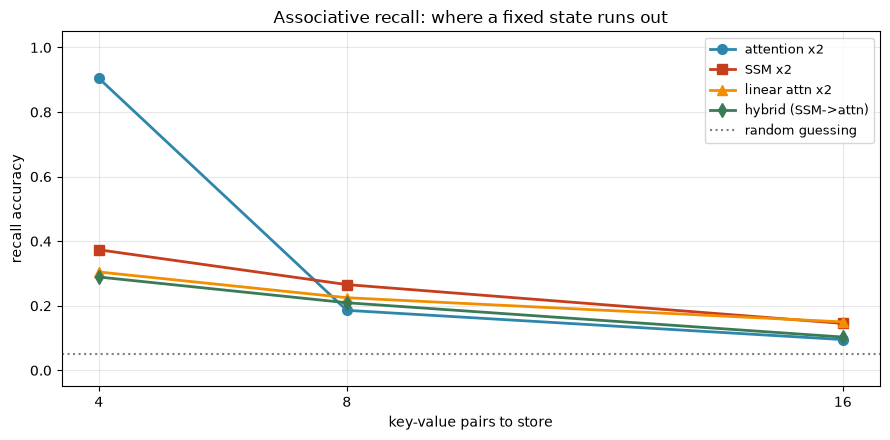

Attention holds up as the number of pairs grows -- it keeps every token.
The fixed-state models degrade, because retrieving one pair out of a
compressed sum gets harder with every pair added.

And the hybrid: a single attention layer on top of an SSM layer
recovers most of the gap. That result, at real scale, is the entire
argument for hybrid architectures.


In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))

colors = {'attention x2': '#2E86AB', 'SSM x2': '#C73E1D',
          'linear attn x2': '#F18F01', 'hybrid (SSM->attn)': '#3B7A57'}
markers = {'attention x2': 'o', 'SSM x2': 's',
           'linear attn x2': '^', 'hybrid (SSM->attn)': 'd'}

for label, accs in results.items():
    ax.plot(pair_counts, accs, marker=markers[label], color=colors[label],
            label=label, lw=2, markersize=7)

ax.axhline(1 / NUM_VALUES, ls=':', color='gray', label='random guessing')
ax.set_xlabel('key-value pairs to store')
ax.set_ylabel('recall accuracy')
ax.set_title('Associative recall: where a fixed state runs out')
ax.set_xticks(pair_counts)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Attention holds up as the number of pairs grows -- it keeps every token.")
print("The fixed-state models degrade, because retrieving one pair out of a")
print("compressed sum gets harder with every pair added.")
print("\nAnd the hybrid: a single attention layer on top of an SSM layer")
print("recovers most of the gap. That result, at real scale, is the entire")
print("argument for hybrid architectures.")

## 7. Hybrid architectures — the current answer

The measurement above is the whole story in miniature, and it is why no frontier model is
either pure attention or pure SSM.

| Architecture | Attention layers | Notes |
|---|---|---|
| **Jamba** (AI21, 2024) | 1 in 8 | Mamba + MoE, 256k context |
| **Samba** (Microsoft, 2024) | alternating | Mamba + sliding-window attention |
| **Zamba** (Zyphra, 2024) | one shared block, reused | Amortizes the attention cost |
| **Gemma 2 / 3** (Google) | alternating local/global | Not SSM, but the same idea: most layers cheap, some global |
| **MiniMax-01** (2025) | 1 in 8 | Lightning (linear) attention + periodic full attention |

The pattern is consistent: **a few full-attention layers are enough** to provide the exact
retrieval that in-context learning needs, and the rest of the network can be cheap. You get
close to attention's quality at close to linear cost.

There is a satisfying explanation for why so few attention layers suffice. The retrieval
circuit — the induction head — needs only a couple of layers to form: one to identify the
matching key, one to copy the value. Every *other* layer is doing local feature processing,
which a recurrence handles perfectly well.

In [16]:
# What the hybrid ratio buys, in cache terms
def hybrid_cache_per_token(num_layers, attn_every, num_kv_heads, head_dim,
                           d_model, d_state=16):
    """KV cache for attention layers, plus constant SSM state for the rest."""
    n_attn = num_layers // attn_every
    n_ssm = num_layers - n_attn
    attn_cache = n_attn * 2 * num_kv_heads * head_dim      # grows with T
    ssm_state = n_ssm * d_model * d_state                  # constant in T
    return attn_cache, ssm_state


layers, kv_heads, head_dim, d_model = 32, 8, 128, 4096

print(f"{'architecture':<26} {'per-token cache':>17} {'fixed state':>13} "
      f"{'cache at 128k':>15}")
print("-" * 76)
for every, name in ((1, 'all attention'), (4, 'hybrid 1:4'),
                    (8, 'hybrid 1:8'), (None, 'all SSM')):
    if every is None:
        per_token, fixed = 0, layers * d_model * 16
    else:
        per_token, fixed = hybrid_cache_per_token(
            layers, every, kv_heads, head_dim, d_model
        )
    at_128k = per_token * 131072 * 2 / 1e9
    print(f"{name:<26} {per_token:>17,} {fixed:>13,} {at_128k:>14.1f}G")

print("\nA 1:8 hybrid cuts the growing part of the cache by 8x while keeping")
print("enough attention for exact retrieval. The fixed SSM state is a rounding")
print("error by comparison -- and unlike the cache, it does not grow with")
print("context OR with batch size.")

architecture                 per-token cache   fixed state   cache at 128k
----------------------------------------------------------------------------
all attention                         65,536             0           17.2G
hybrid 1:4                            16,384     1,572,864            4.3G
hybrid 1:8                             8,192     1,835,008            2.1G
all SSM                                    0     2,097,152            0.0G

A 1:8 hybrid cuts the growing part of the cache by 8x while keeping
enough attention for exact retrieval. The fixed SSM state is a rounding
error by comparison -- and unlike the cache, it does not grow with
context OR with batch size.


### And the newest direction: better recurrences

One more development worth knowing. Linear attention's update `S += k vᵀ` only adds. Recent
work reframes the recurrence as an **online learning problem**: the state is a little model
being fit to map keys to values, and each token is a gradient step.

Under that view, `S += k vᵀ` is plain gradient descent on a squared loss. The **delta
rule** does better — it *corrects* the existing state instead of blindly accumulating:

`S ← S(I − β k kᵀ) + β v kᵀ`

The extra term subtracts what the state already predicts for `k`, so writing a new value for
a key **overwrites** the old one rather than superimposing it. That is precisely the failure
mode section 4 measured.

This is the basis of DeltaNet, Gated DeltaNet, Mamba-2, and Titans. It is the most active
area in sequence-model architecture right now — and it is an attempt to get exact-retrieval
behaviour out of a fixed state, which would remove the need for hybrids at all.

In [17]:
# Additive accumulation vs the delta rule, on the exact failure case:
# writing two different values for the SAME key.
d = 16
key = F.normalize(torch.randn(d), dim=0)
old_value = torch.randn(d)
new_value = torch.randn(d)

# Additive: both values are superimposed and neither is recoverable
S_add = torch.outer(old_value, key)
S_add = S_add + torch.outer(new_value, key)

# Delta rule: subtract the current prediction before writing
beta = 1.0
S_delta = torch.outer(old_value, key)
prediction = S_delta @ key
S_delta = S_delta + beta * torch.outer(new_value - prediction, key)

print("Wrote value A for a key, then value B for the SAME key.")
print("Querying with that key should return B.\n")
for name, S in (("additive (linear attn)", S_add), ("delta rule", S_delta)):
    got = S @ key
    print(f"{name:<26} cos-sim to B: "
          f"{F.cosine_similarity(got, new_value, dim=0):.4f}   "
          f"to A: {F.cosine_similarity(got, old_value, dim=0):+.4f}")

print("\nThe additive state returns a blend of both. The delta rule returns B")
print("and has genuinely forgotten A. Being able to OVERWRITE is what a fixed")
print("state needs in order to behave like memory rather than an accumulator.")

Wrote value A for a key, then value B for the SAME key.
Querying with that key should return B.

additive (linear attn)     cos-sim to B: 0.7576   to A: +0.7003
delta rule                 cos-sim to B: 1.0000   to A: +0.0647

The additive state returns a blend of both. The delta rule returns B
and has genuinely forgotten A. Being able to OVERWRITE is what a fixed
state needs in order to behave like memory rather than an accumulator.


## Summary

Every architecture in this notebook sits somewhere on one trade-off: **state size versus
retrieval ability.**

**The quadratic bill.** Attention FLOPs overtake the projections at `T = 2·d_model`. At 128k
context, attention is ~97% of a layer's compute. FlashAttention fixed the *memory*, not the
FLOPs.

**Why the 2020 efficient-attention wave lost.** Sparse patterns were hand-designed and
GPU-hostile; low-rank projections cannot generate autoregressively (their parameters depend
on `T`); kernel approximations lost quality. An approximation that costs quality loses to an
exact method that costs memory.

**MLA** compresses the hidden state to a low-rank latent and caches only that — 57x smaller
than MHA at DeepSeek-V2's dimensions, better than even MQA, while keeping 128 query heads.
Its subtlety is **decoupled RoPE**: position-dependent rotation would break the
up-projection absorption trick, so position lives in a small separate shared component.

**Linear attention** is a reassociation: `φ(q)ᵀ(Σφ(k)vᵀ)` instead of `(qᵀk)v`. Causally, it
becomes a recurrence with a `d×d` matrix state — so it *is* an RNN, with a parallel training
form and a constant-memory inference form. We verified both give identical results.

**SSMs / Mamba** generalize that recurrence with a learned decay (it can forget) and
**input-dependent** `Δ`, `B`, `C` (it can choose). Selectivity is what made SSMs
language-competitive, at the cost of the convolutional form — recovered via associative scan.

**The measurement that decides everything.** On associative recall, attention holds accuracy
as pairs increase while fixed-state models degrade. A hybrid with a *single* attention layer
recovers most of the gap.

### Key Takeaways

1. **State size versus recall is the fundamental trade-off.** Attention: unbounded state,
   perfect recall, quadratic cost. Recurrence: fixed state, lossy recall, linear cost.
2. **Linear attention is an RNN.** The parallel and recurrent forms are the same model —
   train with one, serve with the other and drop the KV cache entirely.
3. **Selectivity is what makes SSMs work.** Without input-dependent parameters an SSM is
   just a convolution and cannot treat important tokens differently.
4. **MLA optimizes bandwidth, not FLOPs.** It adds compute to shrink the cache — the right
   trade during memory-bound decode (notebook 21).
5. **Decoupled RoPE exists because rotation doesn't commute with up-projection.** A good
   example of a positional-encoding detail dictating an architecture.
6. **Hybrids won.** A few full-attention layers supply the exact retrieval that in-context
   learning needs; the rest can be cheap. 1:8 is a common ratio.
7. **The delta rule is the direction to watch.** Overwriting instead of accumulating is how
   a fixed state might eventually behave like real memory.

### Self-check

- At what sequence length does attention overtake the projections in FLOPs? Derive it.
- Why can Linformer not be used in a decoder?
- What exactly does MLA cache, and why is that smaller than MQA's cache?
- Why does RoPE break MLA's absorption trick, and what is the fix?
- Show that causal linear attention is a recurrence. What is the hidden state?
- Why does linear attention have no KV cache at all?
- What breaks if you make an SSM's `Δ`, `B`, `C` fixed instead of input-dependent?
- Why does one attention layer in eight recover most of pure attention's recall?
- What does the delta rule fix about `S += k vᵀ`?

### What's next

Notebook 17 builds **Mixture-of-Experts** — the other way to decouple cost from capacity,
this time by making the *feed-forward* network sparse rather than the attention.

### References

- Beltagy et al., 2020 — [Longformer](https://arxiv.org/abs/2004.05150)
- Zaheer et al., 2020 — [BigBird](https://arxiv.org/abs/2007.14062)
- Wang et al., 2020 — [Linformer](https://arxiv.org/abs/2006.04768)
- Choromanski et al., 2020 — [Performer](https://arxiv.org/abs/2009.14794)
- Katharopoulos et al., 2020 — [Transformers are RNNs](https://arxiv.org/abs/2006.16236) (linear attention, the recurrent form)
- Shazeer, 2019 — [MQA](https://arxiv.org/abs/1911.02150) · Ainslie et al., 2023 — [GQA](https://arxiv.org/abs/2305.13245)
- DeepSeek-AI, 2024 — [DeepSeek-V2](https://arxiv.org/abs/2405.04434) (MLA) · [DeepSeek-V3](https://arxiv.org/abs/2412.19437)
- Gu et al., 2021 — [S4: Efficiently Modeling Long Sequences with Structured State Spaces](https://arxiv.org/abs/2111.00396)
- Gu & Dao, 2023 — [Mamba: Linear-Time Sequence Modeling with Selective State Spaces](https://arxiv.org/abs/2312.00752)
- Dao & Gu, 2024 — [Transformers are SSMs (Mamba-2)](https://arxiv.org/abs/2405.21060)
- Yang et al., 2024 — [Gated Delta Networks](https://arxiv.org/abs/2412.06464)
- Lieber et al., 2024 — [Jamba](https://arxiv.org/abs/2403.19887)
- Ren et al., 2024 — [Samba](https://arxiv.org/abs/2406.07522)
- Olsson et al., 2022 — [In-context Learning and Induction Heads](https://arxiv.org/abs/2209.11895)
- Arora et al., 2023 — [Zoology: Measuring and Improving Recall in Efficient Language Models](https://arxiv.org/abs/2312.04927) (the associative-recall analysis)